# Import Libraries

In [133]:
# pip install cell – run once if needed
# !pip install nltk scipy tabulate wordcloud scikit-learn matplotlib seaborn pandas numpy

# Core
import numpy as np
import pandas as pd
import re, string

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Sklearn – metrics
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)

# Sklearn – feature extraction & model selection
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# Sklearn – models
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Tabulate (for .to_markdown())
import tabulate  

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set up inline plotting
%matplotlib inline


# Dataset Loading & Preprocessing

In [134]:
# 2.1  Load CSV
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [135]:
# 2.2  Rename & drop
df.rename(columns={'v1': 'Category', 'v2': 'text'}, inplace=True)
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df.head()

,Category,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [136]:
# 2.3  Encode target: ham→0, spam→1
df['spam'] = df['Category'].map({'ham': 0, 'spam': 1})
df.head()

,Category,text,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [137]:
# 2.4  Remove duplicate rows
print(f'Rows before dropping duplicates: {len(df)}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows after dropping duplicates : {len(df)}')

Rows before dropping duplicates: 5572
Rows after dropping duplicates : 5169


In [138]:
# 2.5  Text cleaning function
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Lowercase, remove punctuation, extra whitespace, and stopwords."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = ' '.join(w for w in text.split() if w not in STOP_WORDS)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']]

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
...,...,...
5164,This is the 2nd time we have tried 2 contact u...,nd time tried contact u u å£ pound prize claim...
5165,Will Ì_ b going to esplanade fr home?,ì b going esplanade fr home
5166,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestions
5167,The guy did some bitching but I acted like i'd...,guy bitching acted like id interested buying s...


In [139]:
# 2.6  Feature engineering columns
df['char_count']          = df['text'].apply(len)
df['word_count']          = df['text'].apply(lambda t: len(t.split()))
df['has_currency_symbol'] = df['text'].apply(lambda t: bool(re.search(r'[\$\£\€\¥]', t)))
df['has_numbers']         = df['text'].apply(lambda t: bool(re.search(r'\d', t)))
df['exclamation_count']   = df['text'].apply(lambda t: t.count('!'))

df.head()

,Category,text,spam,clean_text,char_count,word_count,has_currency_symbol,has_numbers,exclamation_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,go jurong point crazy available bugis n great ...,111,20,False,False,0
1,ham,Ok lar... Joking wif u oni...,0,ok lar joking wif u oni,29,6,False,False,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry wkly comp win fa cup final tkts st ...,155,28,False,True,0
3,ham,U dun say so early hor... U c already then say...,0,u dun say early hor u c already say,49,11,False,False,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,nah dont think goes usf lives around though,61,13,False,False,0


# EDA & Visualisation

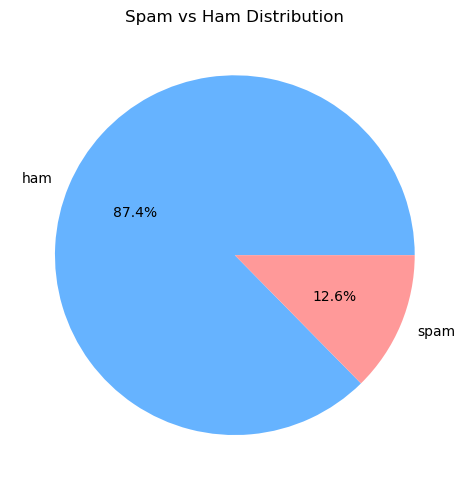

In [140]:
# 3.1  Pie chart – spam vs ham distribution
fig, ax = plt.subplots(figsize=(5, 5))
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                    colors=['#66b3ff','#ff9999'], ax=ax)
ax.set_title('Spam vs Ham Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

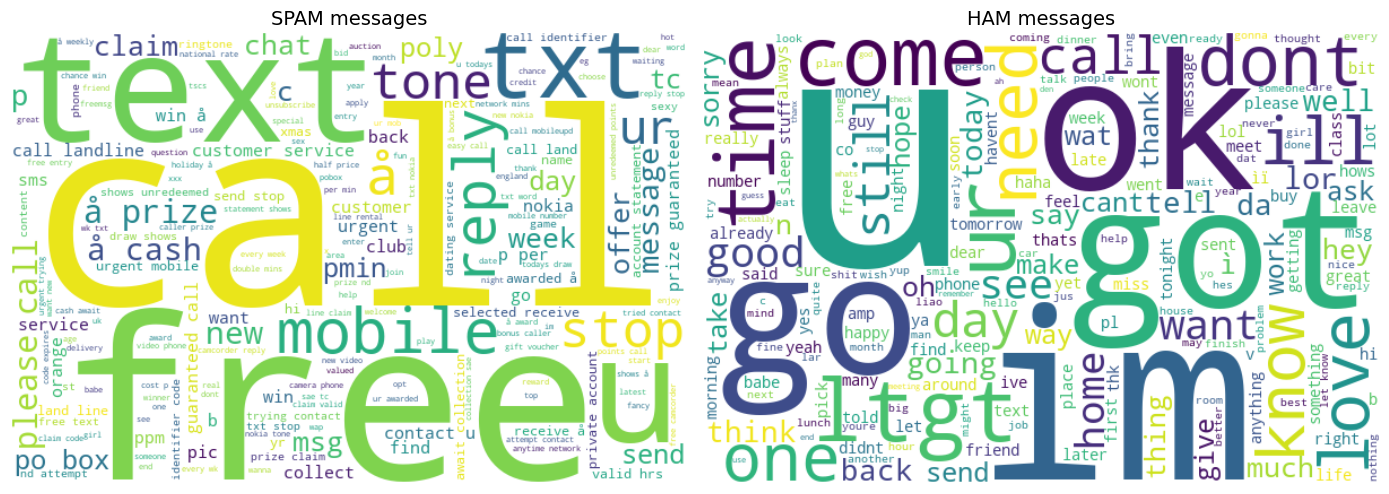

In [141]:
# 3.2  WordClouds – spam & ham side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, label in enumerate(['spam', 'ham']):
    corpus = ' '.join(df.loc[df['Category'] == label, 'clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap='viridis').generate(corpus)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{label.upper()} messages', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

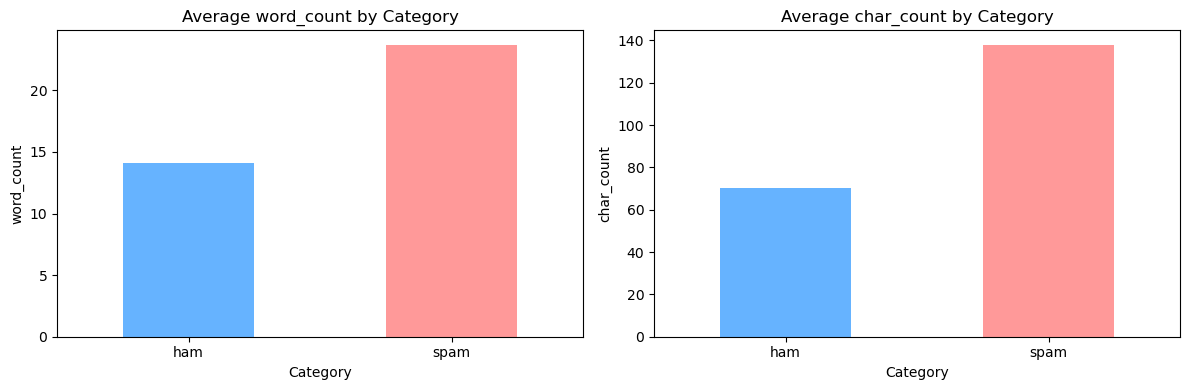

In [142]:
# 3.3  Bar chart – average word_count & char_count for spam vs ham
avg_df = df.groupby('Category')[['word_count', 'char_count']].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['word_count', 'char_count']):
    avg_df[col].plot(kind='bar', ax=axes[i], color=['#66b3ff','#ff9999'])
    axes[i].set_title(f'Average {col} by Category')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

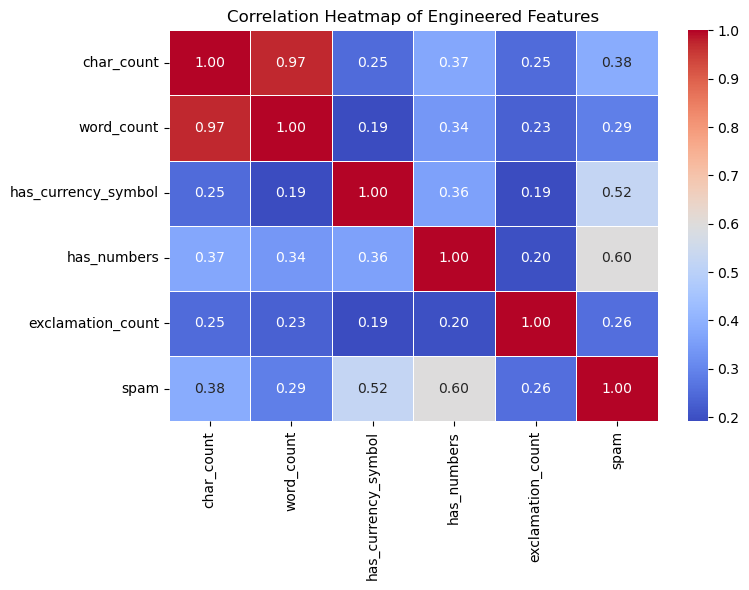

In [143]:
# 3.4  Correlation heatmap of engineered numeric features
numeric_feats = ['char_count', 'word_count', 'has_currency_symbol',
                 'has_numbers', 'exclamation_count', 'spam']
corr = df[numeric_feats].astype(float).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Engineered Features')
plt.tight_layout()
plt.show()

# Feature Extraction & Train/Test Split

In [144]:
# 4.1  TF-IDF vectorisation
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text'])

# 4.2  Combine TF-IDF with numeric engineered features
eng_cols = ['char_count', 'word_count', 'has_currency_symbol',
            'has_numbers', 'exclamation_count']
import scipy.sparse as sp
X_eng = sp.csr_matrix(df[eng_cols].values.astype(float))
X_combined = hstack([X_tfidf, X_eng])

y = df['spam']

In [145]:
# 4.3  Train / test split  80/20, random_state=42
x_train, x_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.20, random_state=42
)

# Build feature-name list for importance plots later
feature_names = list(tfidf.get_feature_names_out()) + eng_cols

print(f'x_train shape: {x_train.shape}')
print(f'x_test  shape: {x_test.shape}')

x_train shape: (4135, 5005)
x_test  shape: (1034, 5005)


# evaluate_model Function

In [146]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Fit, predict, print metrics, plot ROC & confusion matrices,
    optionally plot top-20 feature importances.
    Returns [precision_train, precision_test, recall_train, recall_test,
             acc_train, acc_test, roc_auc_train, roc_auc_test,
             F1_train, F1_test]
    """
    # --- 1. Fit ---
    model.fit(X_train, y_train)

    # --- 2. Predict ---
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # --- 3. Probabilities / decision function for ROC-AUC ---
    if hasattr(model, 'predict_proba'):
        y_prob_train = model.predict_proba(X_train)[:, 1]
        y_prob_test  = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob_train = model.decision_function(X_train)
        y_prob_test  = model.decision_function(X_test)
    else:
        y_prob_train = y_pred_train.astype(float)
        y_prob_test  = y_pred_test.astype(float)

    roc_auc_train = roc_auc_score(y_train, y_prob_train)
    roc_auc_test  = roc_auc_score(y_test,  y_prob_test)

    # --- 4. Print ROC-AUC ---
    print(f'\nTrain ROC AUC : {roc_auc_train:.4f}')
    print(f'Test  ROC AUC : {roc_auc_test:.4f}')

    # --- 5. ROC curve ---
    plt.figure(figsize=(7, 5))
    for y_true, y_prob, label in [
        (y_train, y_prob_train, 'Train'),
        (y_test,  y_prob_test,  'Test')]:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_score(y_true, y_prob):.4f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 6. Confusion matrices side by side ---
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, y_true, y_pred, title in [
        (axes[0], y_train, y_pred_train, 'Train'),
        (axes[1], y_test,  y_pred_test,  'Test')]:
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, ax=ax, cmap='Blues',
            values_format='d')
        ax.set_title(f'{title} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    # --- 7. Classification reports as markdown ---
    cr_train = classification_report(y_train, y_pred_train, output_dict=True)
    cr_test  = classification_report(y_test,  y_pred_test,  output_dict=True)
    print('\nTrain Classification Report:')
    print(pd.DataFrame(cr_train).T.to_markdown())
    print('\nTest Classification Report:')
    print(pd.DataFrame(cr_test).T.to_markdown())

    # --- 8. Feature importances (tree-based only) ---
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        top_n = 20
        indices = np.argsort(importances)[::-1][:top_n]
        names = [feature_names[i] if i < len(feature_names) else f'f{i}'
                 for i in indices]
        plt.figure(figsize=(10, 5))
        plt.bar(range(top_n), importances[indices])
        plt.xticks(range(top_n), names, rotation=45, ha='right')
        plt.title(f'Top {top_n} Feature Importances')
        plt.xlabel('Feature')
        plt.ylabel('Importance')
        plt.tight_layout()
        plt.show()

    # --- 9. Collect scores ---
    precision_train = precision_score(y_train, y_pred_train, average='weighted')
    precision_test  = precision_score(y_test,  y_pred_test,  average='weighted')
    recall_train    = recall_score(y_train, y_pred_train, average='weighted')
    recall_test     = recall_score(y_test,  y_pred_test,  average='weighted')
    acc_train       = accuracy_score(y_train, y_pred_train)
    acc_test        = accuracy_score(y_test,  y_pred_test)
    F1_train        = f1_score(y_train, y_pred_train, average='weighted')
    F1_test         = f1_score(y_test,  y_pred_test,  average='weighted')

    return [precision_train, precision_test,
            recall_train,    recall_test,
            acc_train,       acc_test,
            roc_auc_train,   roc_auc_test,
            F1_train,        F1_test]


# Model Training & Evaluation

## 6.1  ComplementNB


Train ROC AUC : 0.9383
Test  ROC AUC : 0.9087


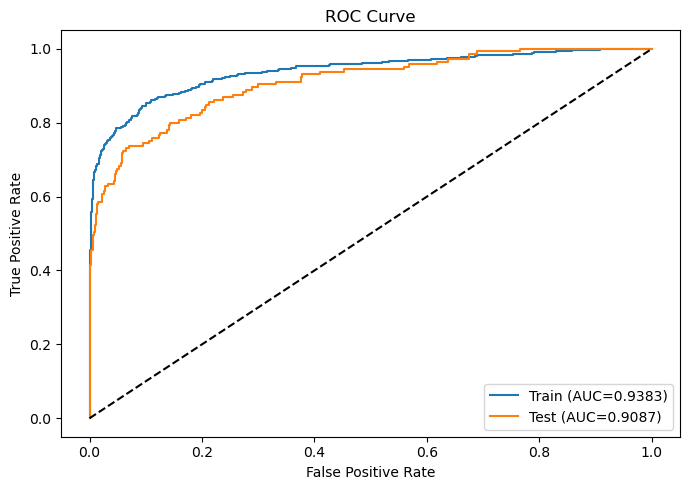

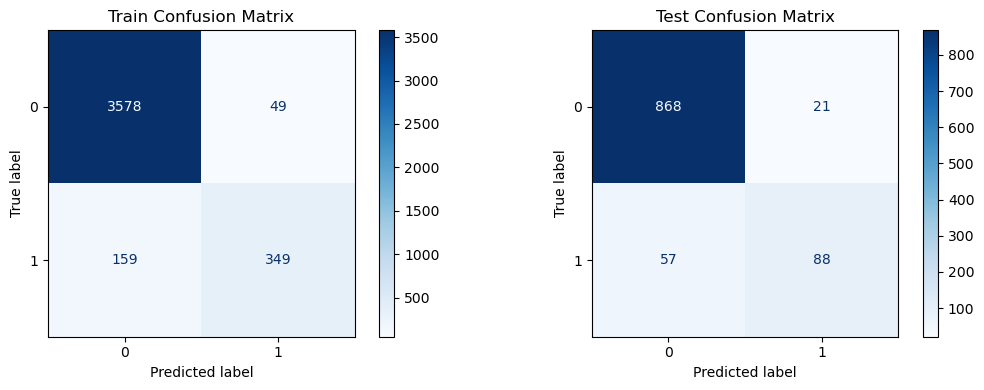


Train Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.957453 | 0.98649  |   0.971754 | 3627        |
| 1            |    0.876884 | 0.687008 |   0.770419 |  508        |
| accuracy     |    0.949698 | 0.949698 |   0.949698 |    0.949698 |
| macro avg    |    0.917168 | 0.836749 |   0.871087 | 4135        |
| weighted avg |    0.947554 | 0.949698 |   0.94702  | 4135        |

Test Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.938378 | 0.976378 |   0.957001 |  889        |
| 1            |    0.807339 | 0.606897 |   0.692913 |  145        |
| accuracy     |    0.924565 | 0.924565 |   0.924565 |    0.924565 |
| macro avg    |    0.872859 | 0.791637 |   0.824957 | 1034        |
| weighted avg |    0.920003 | 0.924565 |   

In [147]:
# 6.1  ComplementNB
complement_nb = ComplementNB()
ComplementNB_score = evaluate_model(complement_nb, x_train, x_test, y_train, y_test)

## 6.2  Logistic Regression


Train ROC AUC : 0.9912
Test  ROC AUC : 0.9911


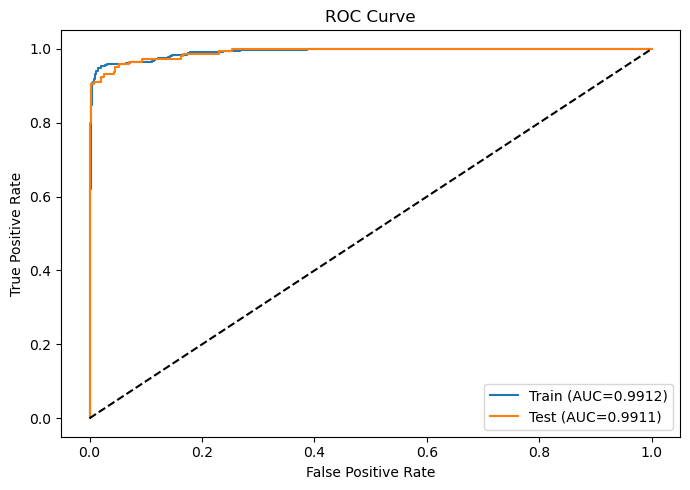

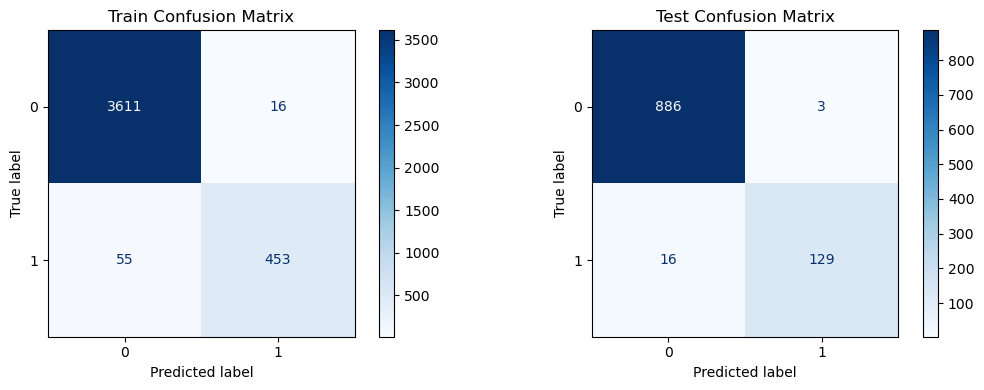


Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.984997 | 0.995589 |   0.990265 | 3627       |
| 1            |    0.965885 | 0.891732 |   0.927329 |  508       |
| accuracy     |    0.98283  | 0.98283  |   0.98283  |    0.98283 |
| macro avg    |    0.975441 | 0.94366  |   0.958797 | 4135       |
| weighted avg |    0.982649 | 0.98283  |   0.982533 | 4135       |

Test Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.982262 | 0.996625 |   0.989391 |  889        |
| 1            |    0.977273 | 0.889655 |   0.931408 |  145        |
| accuracy     |    0.981625 | 0.981625 |   0.981625 |    0.981625 |
| macro avg    |    0.979767 | 0.94314  |   0.9604   | 1034        |
| weighted avg |    0.981562 | 0.981625 |   0.98126

In [148]:
# 6.2  Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
LR_score = evaluate_model(lr, x_train, x_test, y_train, y_test)

## 6.3  LinearSVC (SVM)


Train ROC AUC : 0.9924
Test  ROC AUC : 0.9948


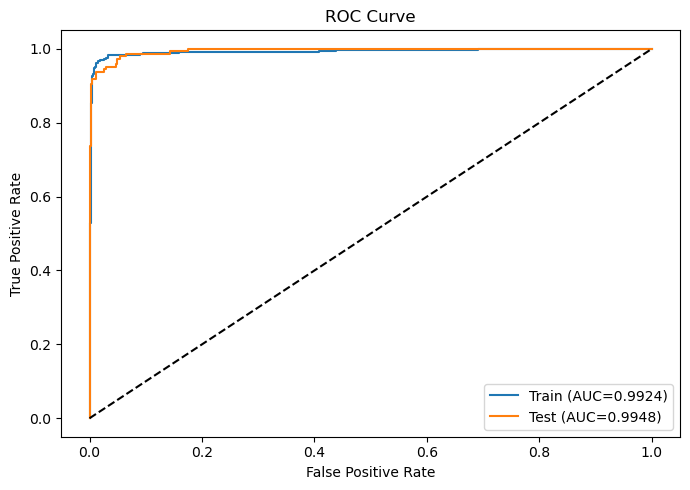

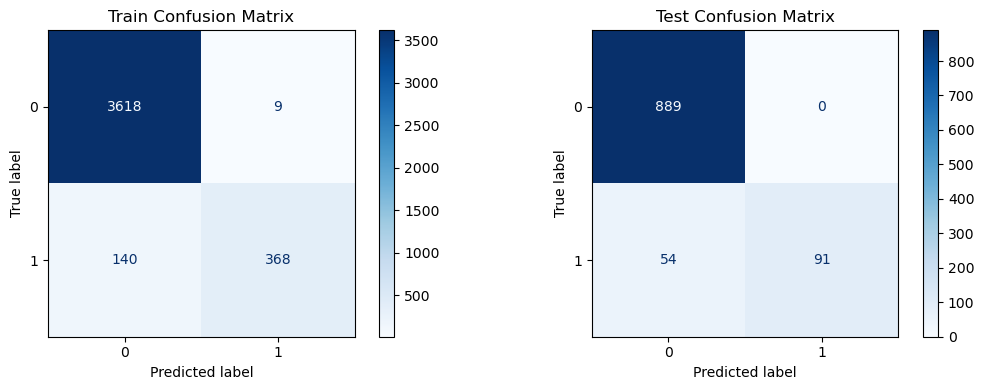


Train Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.962746 | 0.997519 |   0.979824 | 3627        |
| 1            |    0.976127 | 0.724409 |   0.831638 |  508        |
| accuracy     |    0.963966 | 0.963966 |   0.963966 |    0.963966 |
| macro avg    |    0.969437 | 0.860964 |   0.905731 | 4135        |
| weighted avg |    0.96439  | 0.963966 |   0.961619 | 4135        |

Test Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.942736 | 1        |   0.970524 |  889        |
| 1            |    1        | 0.627586 |   0.771186 |  145        |
| accuracy     |    0.947776 | 0.947776 |   0.947776 |    0.947776 |
| macro avg    |    0.971368 | 0.813793 |   0.870855 | 1034        |
| weighted avg |    0.950766 | 0.947776 |   

In [149]:
# 6.3  LinearSVC (SVM)
svm = LinearSVC(max_iter=2000, random_state=42)
SVM_score = evaluate_model(svm, x_train, x_test, y_train, y_test)

## 6.4  Random Forest


Train ROC AUC : 1.0000
Test  ROC AUC : 0.9907


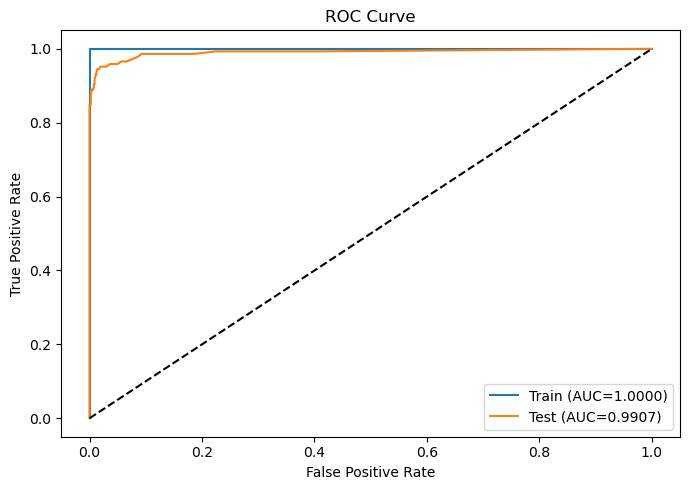

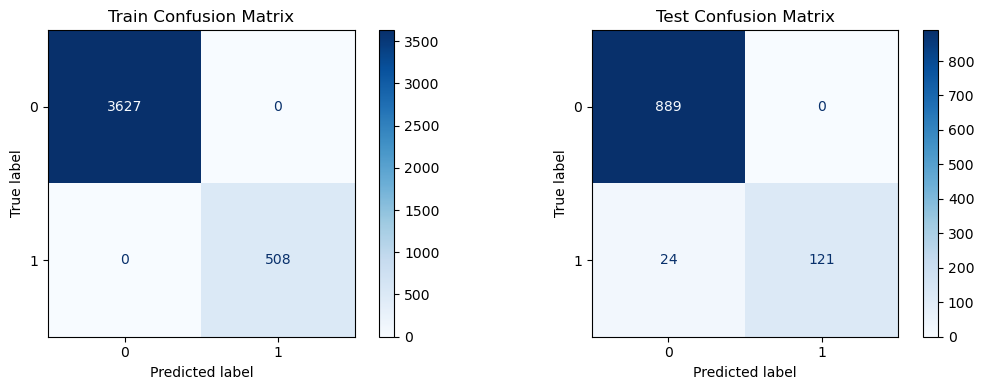


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |      3627 |
| 1            |           1 |        1 |          1 |       508 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |      4135 |
| weighted avg |           1 |        1 |          1 |      4135 |

Test Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.973713 | 1        |   0.986681 |  889        |
| 1            |    1        | 0.834483 |   0.909774 |  145        |
| accuracy     |    0.976789 | 0.976789 |   0.976789 |    0.976789 |
| macro avg    |    0.986857 | 0.917241 |   0.948228 | 1034        |
| weighted avg |    0.977399 | 0.976789 |   0.975897 | 103

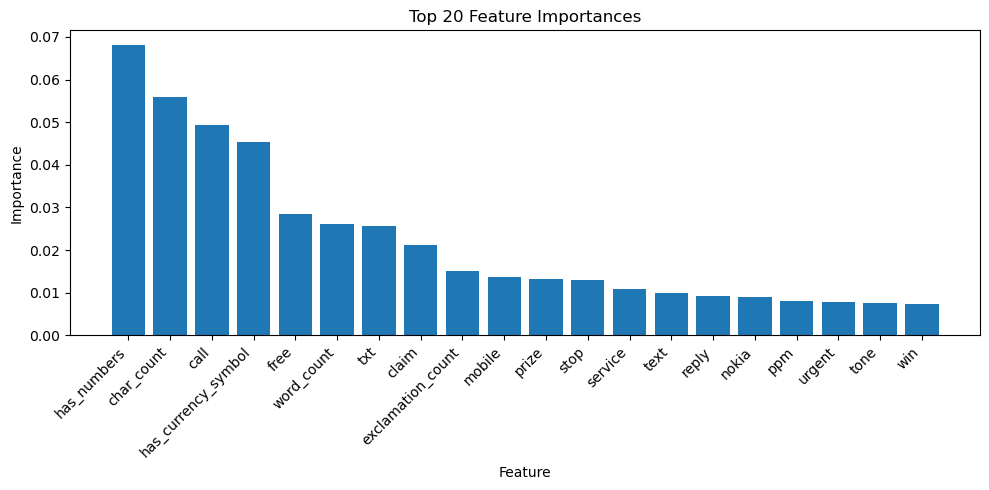

In [150]:
# 6.4  Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
RF_score = evaluate_model(rf, x_train, x_test, y_train, y_test)

## 6.5  Decision Tree


Train ROC AUC : 1.0000
Test  ROC AUC : 0.9162


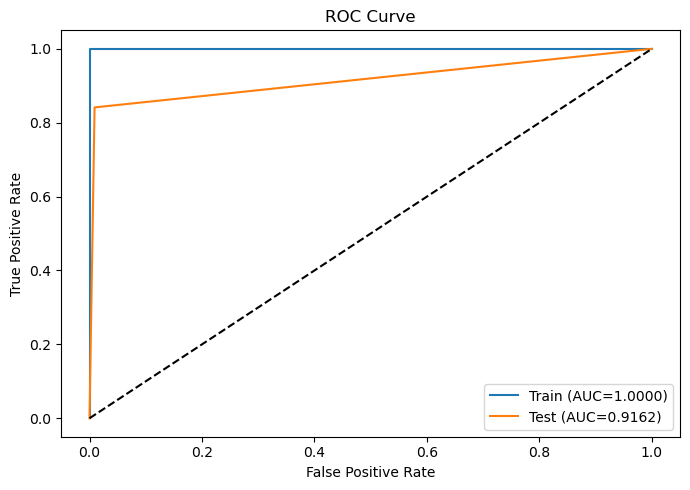

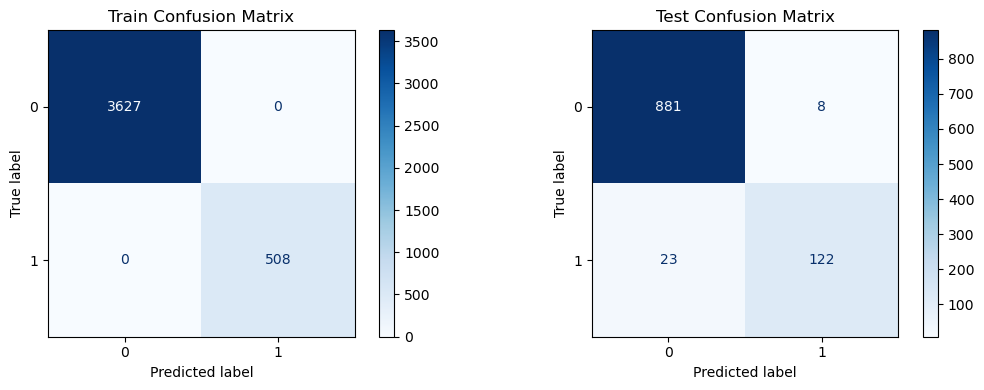


Train Classification Report:
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |      3627 |
| 1            |           1 |        1 |          1 |       508 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |        1 |          1 |      4135 |
| weighted avg |           1 |        1 |          1 |      4135 |

Test Classification Report:
|              |   precision |   recall |   f1-score |     support |
|:-------------|------------:|---------:|-----------:|------------:|
| 0            |    0.974558 | 0.991001 |   0.982711 |  889        |
| 1            |    0.938462 | 0.841379 |   0.887273 |  145        |
| accuracy     |    0.970019 | 0.970019 |   0.970019 |    0.970019 |
| macro avg    |    0.95651  | 0.91619  |   0.934992 | 1034        |
| weighted avg |    0.969496 | 0.970019 |   0.969327 | 103

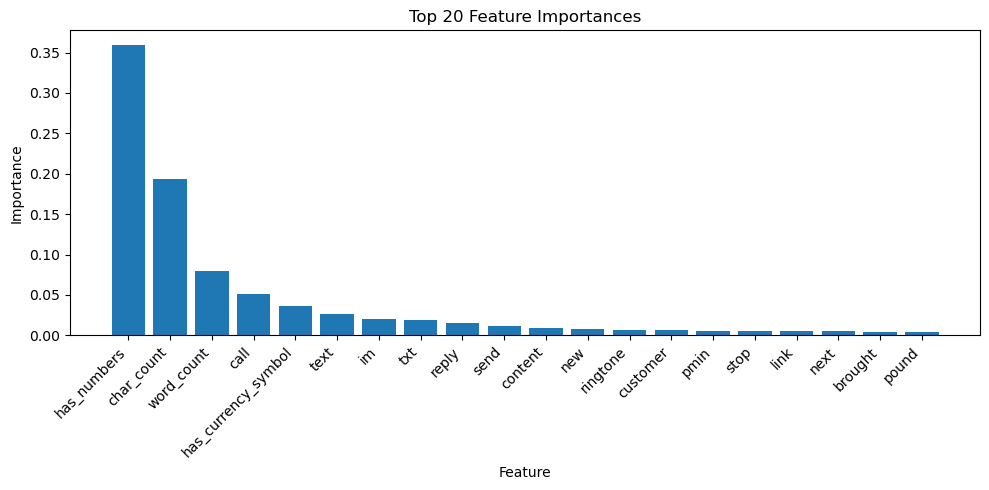

In [151]:
# 6.5  Decision Tree
dt = DecisionTreeClassifier(random_state=42)
DT_score = evaluate_model(dt, x_train, x_test, y_train, y_test)

# Model Comparison

In [152]:
# Collect all scores
columns = ['Precision_Train', 'Precision_Test',
           'Recall_Train',    'Recall_Test',
           'Acc_Train',       'Acc_Test',
           'ROC_AUC_Train',   'ROC_AUC_Test',
           'F1_Train',        'F1_Test']

model_names = ['ComplementNB', 'LogisticRegression', 'SVM',
               'RandomForest', 'DecisionTree']
all_scores  = [ComplementNB_score, LR_score, SVM_score,
               RF_score, DT_score]

comparison_df = pd.DataFrame(all_scores, columns=columns, index=model_names)
print(comparison_df.to_markdown())

|                    |   Precision_Train |   Precision_Test |   Recall_Train |   Recall_Test |   Acc_Train |   Acc_Test |   ROC_AUC_Train |   ROC_AUC_Test |   F1_Train |   F1_Test |
|:-------------------|------------------:|-----------------:|---------------:|--------------:|------------:|-----------:|----------------:|---------------:|-----------:|----------:|
| ComplementNB       |          0.947554 |         0.920003 |       0.949698 |      0.924565 |    0.949698 |   0.924565 |        0.938286 |       0.908716 |   0.94702  |  0.919968 |
| LogisticRegression |          0.982649 |         0.981562 |       0.98283  |      0.981625 |    0.98283  |   0.981625 |        0.991235 |       0.991079 |   0.982533 |  0.98126  |
| SVM                |          0.96439  |         0.950766 |       0.963966 |      0.947776 |    0.963966 |   0.947776 |        0.992353 |       0.994826 |   0.961619 |  0.94257  |
| RandomForest       |          1        |         0.977399 |       1        |      0.9767

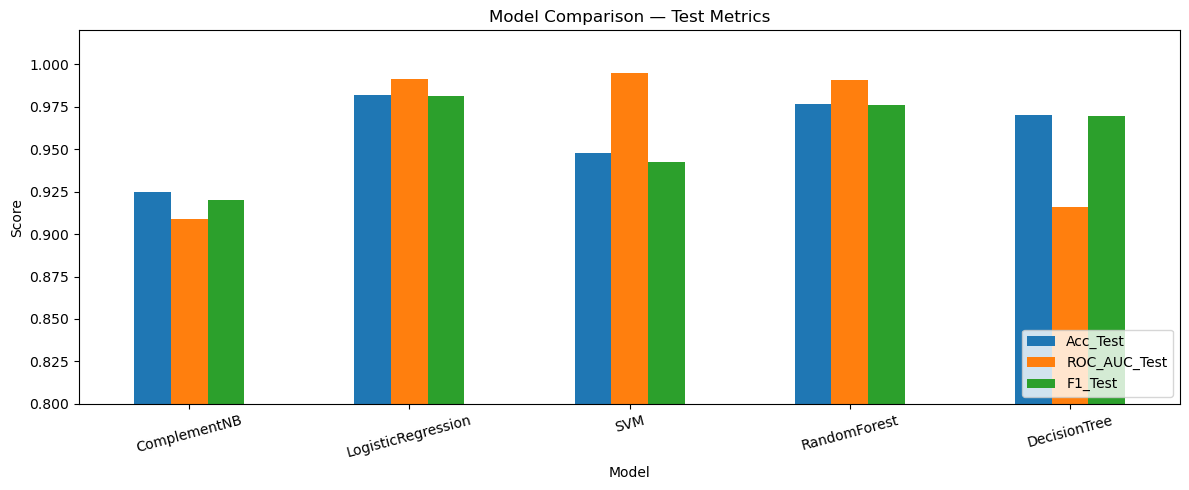

In [153]:
# Grouped bar chart — Acc_Test, ROC_AUC_Test, F1_Test
metrics_to_plot = ['Acc_Test', 'ROC_AUC_Test', 'F1_Test']
plot_df = comparison_df[metrics_to_plot]

ax = plot_df.plot(kind='bar', figsize=(12, 5), rot=15)
ax.set_title('Model Comparison — Test Metrics')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim(0.8, 1.02)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Spam Detection Function

In [154]:
# Identify the best model by F1_Test
best_model_name = comparison_df['F1_Test'].idxmax()
print(f'Best performing model (by F1_Test): {best_model_name}')

best_models = {
    'ComplementNB':      complement_nb,
    'LogisticRegression': lr,
    'LinearSVC':         svm,
    'RandomForest':      rf,
    'DecisionTree':      dt,
}
best_model = best_models[best_model_name]


Best performing model (by F1_Test): LogisticRegression


In [155]:
def detect_spam(email_text, model=None):
    """
    Predict whether an email is Spam or Not Spam.
    Cleans & vectorises the input exactly like training data.
    Returns label string + confidence probability.
    """
    if model is None:
        model = best_model

    # Clean
    cleaned = clean_text(email_text)

    # TF-IDF
    X_tfidf_input = tfidf.transform([cleaned])

    # Engineered features
    char_count = len(email_text)
    word_count = len(email_text.split())
    has_currency = bool(re.search(r'[\$\£\€\¥]', email_text))
    has_nums     = bool(re.search(r'\d', email_text))
    excl_count   = email_text.count('!')
    eng_vec = sp.csr_matrix([[char_count, word_count,
                              int(has_currency), int(has_nums),
                              excl_count]], dtype=float)

    X_input = hstack([X_tfidf_input, eng_vec])

    # Predict
    prediction = model.predict(X_input)[0]

    # Confidence
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_input)[0]
        confidence = prob[prediction]
    elif hasattr(model, 'decision_function'):
        confidence = abs(model.decision_function(X_input)[0])
    else:
        confidence = None

    label = 'Spam' if prediction == 1 else 'Not Spam'
    conf_str = f' (confidence: {confidence:.4f})' if confidence is not None else ''
    return f'{label}{conf_str}'


In [156]:
# Test the detection function
samples = [
    'Congratulations! You have won a luxury vacation package worth $10,000! Click here to claim your prize now!',
    'Hey, are we still meeting for lunch tomorrow?',
    'URGENT: Your account has been compromised. Send your password immediately to secure it.',
    'Can you pick up some milk on your way home?',
]

for s in samples:
    print(f'Email: {s[:80]}...')
    print(f'  → {detect_spam(s)}')
    print()

Email: Congratulations! You have won a luxury vacation package worth $10,000! Click her...
  → Spam (confidence: 0.9743)

Email: Hey, are we still meeting for lunch tomorrow?...
  → Not Spam (confidence: 0.9966)

Email: URGENT: Your account has been compromised. Send your password immediately to sec...
  → Not Spam (confidence: 0.9378)

Email: Can you pick up some milk on your way home?...
  → Not Spam (confidence: 0.9976)

